In [1]:
import json 
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.chdir("/mnt/petrelfs/jiangshuyang/repo/efficient_RL")

In [ ]:


def get_dataset_num(dataset_name):
    dataset_path = os.path.join(f"data/{dataset_name}/test.parquet")
    data = pd.read_parquet(dataset_path)
    num_rows = len(data)
    return num_rows 

def show_results(ckpts, datasets, metric='avg_acc'):
    results = {}
    results['model'] = ckpts
    for dataset_name in datasets:
        results[dataset_name] = []
        results[dataset_name + "_pass@K"] = []
        num_rows = get_dataset_num(dataset_name)
        for ckpt in ckpts:
            result_path = os.path.join(f"results/{dataset_name}/{ckpt}/result.json")
            if dataset_name == 'math':
                result_path = result_path.replace("sc128", "sc16")
            if not os.path.exists(result_path):
                result_path = result_path.replace("sc128", "sc16")
                result_path = result_path.replace("sc32", "sc16")
                if not os.path.exists(result_path):
                    # print(f"Warning: Result file for {dataset_name} at checkpoint {ckpt} not found.")
                    results[dataset_name].append(np.nan)
                    results[dataset_name + "_pass@K"].append(np.nan)
                    continue
                    
            with open(result_path, 'r') as f:
                data = json.load(f)
            if data['count'] != num_rows:
                print(f"Warning: The number of rows in {dataset_name} for checkpoint {ckpt} does not match the expected count.")
            k = (len(data['score']) - 3)
            pass_k = f'pass@{k}'
            results[dataset_name].append(data['score'][metric] * 100)
            results[dataset_name + "_pass@K"].append(data['score'][pass_k] * 100)
            
    df = pd.DataFrame(results)
    
    return df



def show_pass_at_k_fixed(ckpts, datasets):
    # todo: 
    results = {}
    results['model'] = ckpts
    for dataset_name in datasets:
        results[dataset_name] = []
        num_rows = get_dataset_num(dataset_name)
        for ckpt in ckpts:
            result_path = os.path.join(f"results/{dataset_name}/{ckpt}/result.json")
            if not os.path.exists(result_path):
                result_path = result_path.replace("sc128", "sc16")
                result_path = result_path.replace("sc32", "sc16")
                if not os.path.exists(result_path):
                    results[dataset_name].append(np.nan)
                    continue
            with open(result_path, 'r') as f:
                data = json.load(f)
            # print(result_path)
            if 'score' not in data or not isinstance(data['score'], dict):
                results[dataset_name].append(np.nan)
                continue

            k = (len(data['score']) - 3)
            metric = f'pass@{k}'
            
            if metric in data['score']:
                results[dataset_name].append(data['score'][metric] * 100)
            else:
                results[dataset_name].append(np.nan)

    df = pd.DataFrame(results)
    df['avg_score'] = df[datasets].mean(axis=1)
    return df

def show_pass_at_k_results(ckpts, dataset):
    # todo: 
    results = {}
    results['model'] = ckpts
    k_list = [1, 2, 4, 8, 16, 32, 64, 128]
    for k in k_list:
        column_name = str(k)
        results[column_name] = []
        for ckpt in ckpts:
            result_path = os.path.join(f"results/{dataset}/{ckpt}/result.json")
            if not os.path.exists(result_path):
                result_path = result_path.replace("sc128", "sc16")
                result_path = result_path.replace("sc32", "sc16")
                if not os.path.exists(result_path):
                    results[column_name].append(np.nan)
                    continue

            with open(result_path, 'r') as f:
                data = json.load(f)
            
            if 'score' not in data or not isinstance(data['score'], dict):
                results[column_name].append(np.nan)
                continue
            metric = f'pass@{k}'
            if metric in data['score']:
                results[column_name].append(data['score'][metric] * 100)
            else:
                results[column_name].append(np.nan)
    

    df = pd.DataFrame(results)

    return df

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import math


def show_pass_at_k_std_results(ckpts, dataset, k_max=128, runs=5):
    results = {}
    results['model'] = ckpts
    k_list = [1, 2, 4, 8, 16, 32, 64, 128]
    for k in k_list:
        if k > k_max:
            continue
        cur_run = 10
        column_name = str(k)
        results[column_name] = []
        results[column_name + "_std"] = []
        for ckpt in ckpts:
            cache_path = os.path.join(f"results/{dataset}/{ckpt}/cache.jsonl")
            # result_path = os.path.join(f"results/{dataset}/{ckpt}/result.json")
            if not os.path.exists(cache_path):
                
                cache_path = cache_path.replace("sc128", "sc16")
                cache_path = cache_path.replace("sc32", "sc16")
                if not os.path.exists(cache_path):
                    results[column_name].append(np.nan)
                    continue

            data = [json.loads(line) for line in open(cache_path)]
            all_maj_k_acc = []
            all_maj_k_std = []
            for task_log in data:
                all_run_acc = []
                # std_acc = []
                for run in range(cur_run):
                    sample_idx = np.random.choice(len(task_log['predictions']), size=k, replace=True)
                    predictions = [task_log['predictions'][idx] for idx in sample_idx]
                    accuracy = [task_log['all_acc'][idx] for idx in sample_idx]
                    
                    
                    maj_acc = np.any(accuracy)
                    # maj_acc = accuracy[vote_index]
                    
                    # task_log['trajectory'] = task_log['trajectory'][:k]
                    # task_log = score_task(task_log, task_log['task']['dataset'])
                    # maj_acc = task_log['acc']
                    all_run_acc.append(maj_acc)
                maj_acc = np.mean(all_run_acc)
                maj_acc_std = np.std(all_run_acc)
                
                all_maj_k_acc.append(maj_acc)
                all_maj_k_std.append(maj_acc_std)
            
            results[column_name + "_std"].append(np.mean(all_maj_k_std) * 100)
            results[column_name].append(np.mean(all_maj_k_acc) * 100)
            
        

    df = pd.DataFrame(results)

    return df

In [ ]:
def add_aes_score(df, datasets):
    df['avg_score'] = df[datasets].mean(axis=1)
    df['avg_length'] = df[[d + "_len" for d in datasets]].mean(axis=1)
    # add a column named aes, which is computed as below:
    # aes = eta * (df['avg_length'][0]-df['avg_length'])/df['avg_length'][0] + lambda * abs((df['avg_score'] - df['avg_score'][0]) / df['avg_score'][0])
    # where eta = 1 , lambda = 3 for df['avg_score'] > df['avg_score'][0] else -5
    return df

In [5]:
datasets = ['aime2024', 'aime2025', 'amc23', 'hmmt25', 'math', 'olympiad_bench']
# model_list = ['Qwen3-4B-Base_sc16', 'Qwen3-4B-Base_sc128', 'deepscaler_qwen34b_grpo_bsz128_global_step_314_sc128', 'deepscaler_qwen34b_grpo_new_global_step_629_sc16', 'deepscaler_qwen34b_grpo_neg_new_reward_last_global_step_629_sc16', 'deepscaler_qwen34b_grpo_neg_new_reward_global_step_629_sc16', 'deepscaler_qwen34b_ent_inc_bsz128_global_step_314_sc128', 'deepscaler_qwen34b_grpo_dynamicrollout_max_bsz128_global_step_314_sc128']
# model_list = ['Qwen3-4B-Base_sc128', 'deepscaler_qwen34b_grpo_bsz128_global_step_314_sc128', 'deepscaler_qwen34b_grpo_dapo_global_step_179_sc128', 'deepscaler_qwen34b_grpo_bapo_0.8_0.95_1.2_2.0_target_0.5_global_step_314_sc128', 'deepscaler_qwen34b_grpo_kl_cov_global_step_230_sc128', 'deepscaler_qwen34b_grpo_clip_cov_global_step_140_sc128', 'deepscaler_qwen34b_ent_inc_pos0.02_bsz128_global_step_314_sc128', 'deepscaler_qwen34b_ent_inc_pos_005_cmp_klmask_global_step_314_sc128', 'deepscaler_qwen34b_grpo_cmpkl_global_step_314_sc128', 'deepscaler_qwen34b_ent_inc_pos_005_inversecredit_cmp_klmask_global_step_310_sc128']
model_list = ['Qwen3-4B-Base_sc128', 'deepscaler_qwen34b_grpo_bsz128_global_step_314_sc128', 'deepscaler_qwen34b_grpo_dapo_global_step_179_sc128', 'deepscaler_qwen34b_reinforce_plus_plus_baseline_global_step_310_sc128', 'deepscaler_qwen34b_grpo_gspo_global_step_314_sc128_8192', 'deepscaler_qwen34b_ent_inc_pos_scale00015_focalcredit_global_step_325_sc128_8192']

In [7]:
qwen8b_model_list = ['deepscaler_qwen38b_ucas_vanilla_global_step_115_sc128_8192', 'deepscaler_qwen34b_ucas_vanilla_global_step_125_sc128_8192']
qwen8b_df = show_results(qwen8b_model_list,  datasets)
qwen8b_df

,model,aime2024,aime2024_pass@K,aime2025,aime2025_pass@K,amc23,amc23_pass@K,hmmt25,hmmt25_pass@K,math,math_pass@K,olympiad_bench,olympiad_bench_pass@K
0,deepscaler_qwen38b_ucas_vanilla_global_step_11...,22.161458,73.333333,15.338542,53.333333,65.996094,100.0,8.880208,53.333333,84.5375,94.8,53.356282,74.870912
1,deepscaler_qwen34b_ucas_vanilla_global_step_12...,19.088542,56.666667,15.416667,53.333333,60.136719,100.0,9.192708,36.666667,82.8000,94.0,49.462134,70.051635


In [15]:
all_df_128 = show_results(model_list,  datasets)
# 32.92	9190.46	25.42	8921.40	74.84	5917.28

# all_df_16 = add_aes_score(df=all_df_16, datasets=datasets)
all_df_128
# # filter all _len columns 
# all_df_16.loc[:, ~all_df_16.columns.str.contains('_len')]

,model,aime2024,aime2024_pass@K,aime2025,aime2025_pass@K,amc23,amc23_pass@K,hmmt25,hmmt25_pass@K,math,math_pass@K,olympiad_bench,olympiad_bench_pass@K
0,Qwen3-4B-Base_sc128,9.505208,50.000000,6.875000,50.000000,32.910156,97.5,0.989583,26.666667,58.8875,91.0,31.809380,65.404475
1,deepscaler_qwen34b_grpo_bsz128_global_step_314...,19.791667,63.333333,20.338542,63.333333,61.894531,97.5,7.864583,33.333333,83.9125,94.0,52.194492,72.633391
2,deepscaler_qwen34b_grpo_dapo_global_step_179_s...,21.223958,53.333333,18.697917,50.000000,64.511719,95.0,6.718750,30.000000,82.1125,94.4,51.172547,71.256454
3,deepscaler_qwen34b_reinforce_plus_plus_baselin...,15.546875,56.666667,12.682292,43.333333,58.710938,95.0,4.192708,36.666667,79.9000,93.4,46.460843,70.395869
4,deepscaler_qwen34b_grpo_gspo_global_step_314_s...,16.041667,70.000000,11.979167,46.666667,58.085937,97.5,4.531250,30.000000,80.2500,93.4,46.213425,69.879518
5,deepscaler_qwen34b_ent_inc_pos_scale00015_foca...,25.859375,70.000000,21.848958,60.000000,69.882812,97.5,10.807292,50.000000,86.9250,95.8,57.067556,76.247849


In [17]:
ablation_model_list = ['deepscaler_qwen34b_ent_inc_pos_scale00015_focalcredit_global_step_325_sc128_8192', 'deepscaler_qwen34b_abspos_vanilla_global_step_165_sc128_8192', 'deepscaler_qwen34b_ent_inc_pos0.02_bsz128_global_step_314_sc128', 'deepscaler_qwen34b_ent_inc_pos_scale0003_focalcredit_global_step_235_sc128_8192']
ablation_df = show_results(ablation_model_list, datasets)
ablation_df

,model,aime2024,aime2024_pass@K,aime2025,aime2025_pass@K,amc23,amc23_pass@K,hmmt25,hmmt25_pass@K,math,math_pass@K,olympiad_bench,olympiad_bench_pass@K
0,deepscaler_qwen34b_ent_inc_pos_scale00015_foca...,25.859375,70.000000,21.848958,60.000000,69.882812,97.5,10.807292,50.000000,86.9250,95.8,57.067556,76.247849
1,deepscaler_qwen34b_abspos_vanilla_global_step_...,15.494792,53.333333,12.187500,33.333333,57.363281,90.0,2.708333,20.000000,79.6375,91.8,46.589931,68.502582
2,deepscaler_qwen34b_ent_inc_pos0.02_bsz128_glob...,24.427083,66.666667,21.093750,66.666667,68.808594,95.0,10.390625,36.666667,85.9250,95.2,55.260327,76.764200
3,deepscaler_qwen34b_ent_inc_pos_scale0003_focal...,20.234375,66.666667,19.479167,53.333333,60.546875,97.5,7.890625,33.333333,82.9500,96.0,50.871343,73.666093


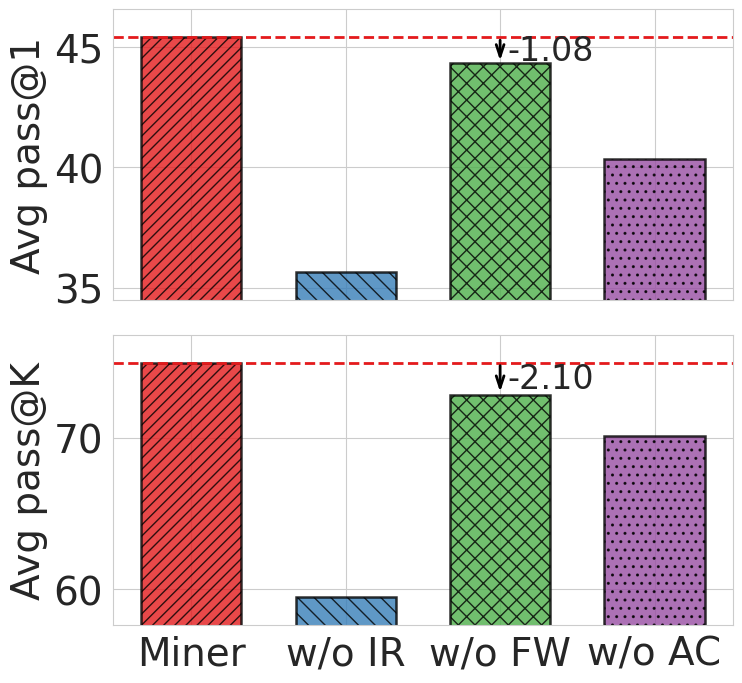

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from matplotlib.lines import Line2D
import matplotlib as mpl
import seaborn as sns
# --- 1) load table (paste exactly as you sent; whitespace-separated is OK) ---
raw = r"""
model	aime2024	aime2024_pass@K	aime2025	aime2025_pass@K	amc23	amc23_pass@K	hmmt25	hmmt25_pass@K	math	math_pass@K	olympiad_bench	olympiad_bench_pass@K
0	deepscaler_qwen34b_ent_inc_pos_scale00015_foca...	25.859375	70.000000	22.97	60.000000	69.882812	97.5	10.807292	46.67	86.9250	95.8	57.067556	76.247849
1	deepscaler_qwen34b_abspos_vanilla_global_step_...	15.494792	53.333333	12.187500	33.333333	57.363281	90.0	2.708333	20.000000	79.6375	91.8	46.589931	68.502582
2	deepscaler_qwen34b_ent_inc_pos0.02_bsz128_glob...	24.427083	66.666667	21.093750	66.666667	68.808594	95.0	10.390625	36.666667	85.9250	95.2	55.260327	76.764200
3	deepscaler_qwen34b_ent_inc_pos_scale0003_focal...	20.234375	66.666667	19.479167	53.333333	60.546875	97.5	7.890625	33.333333	82.9500	96.0	50.871343	73.666093
""".strip()
sns.set_style("whitegrid")
df = ablation_df.copy()

# --- 2) compute avg pass@1 and avg pass@K across tasks ---
pass1_cols = ["aime2024", "aime2025", "amc23", "hmmt25", "math", "olympiad_bench"]
passk_cols = ["aime2024_pass@K", "aime2025_pass@K", "amc23_pass@K", "hmmt25_pass@K", "math_pass@K", "olympiad_bench_pass@K"]

df["avg_pass1"] = df[pass1_cols].mean(axis=1)
df["avg_passk"] = df[passk_cols].mean(axis=1)
set1 = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]  # first 4 from Set1
hatches = ["///", "\\\\", "xx", ".."]  # per-bar patterns

# row order: Ours, w/o IR, w/o FW, w/o AC
exp_names = ["Miner", "w/o IR", "w/o FW", "w/o AC"]
avg_pass1 = df.loc[[0, 1, 2, 3], "avg_pass1"].to_numpy()
avg_passk = df.loc[[0, 1, 2, 3], "avg_passk"].to_numpy()

# --- 3) plot ---
plt.rcParams.update({
    "font.size": 28,
    "axes.labelsize": 28,
    "xtick.labelsize": 28,
    "ytick.labelsize": 28,
})

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(8, 8), sharex=True, gridspec_kw={"hspace": 0.12}
)

x = np.arange(len(exp_names))
bar_w = 0.65

bars1 = ax1.bar(x, avg_pass1, width=bar_w, color=set1, edgecolor="black", linewidth=1.8, alpha=0.8)
bars2 = ax2.bar(x, avg_passk, width=bar_w, color=set1, edgecolor="black", linewidth=1.8, alpha=0.8)
for i, b in enumerate(bars1):
    b.set_hatch(hatches[i % len(hatches)])
for i, b in enumerate(bars2):
    b.set_hatch(hatches[i % len(hatches)])


ax1.set_ylabel("Avg pass@1")
ax2.set_ylabel("Avg pass@K")
ax2.set_xticks(x)
ax2.set_xticklabels(exp_names)

# --- 4) dashed reference lines + arrow annotations (Ours vs best ablation) ---
def add_improvement_annot(ax, ours_val, ablation_vals, y_pad_ratio=0.12):
    best_val = float(np.max(ablation_vals))
    best_idx = int(np.argmax(ablation_vals)) + 1  # +1 because ablations start at index 1
    best_name = exp_names[best_idx]

    # two horizontal dashed lines
    
    ax.axhline(ours_val, linestyle="--", linewidth=2, color=set1[0])
    # ax.axhline(best_val, linestyle="-.", linewidth=2)

    # arrow + text (show improvement of Ours over best ablation)
    delta = ours_val - best_val
    pct = (delta / best_val * 100.0) if best_val != 0 else np.nan

    # place arrow to the right of last bar
    x_arrow = best_idx
    # ax.set_xlim(-0.6, len(exp_names) - 0.4 + 0.8)

    ax.annotate(
        "", xy=(x_arrow, best_val), xytext=(x_arrow, ours_val),
        arrowprops=dict(arrowstyle="->,head_length=0.3,head_width=0.1", linewidth=2, color='black')
    )
    ax.text(
        x_arrow + 0.05, (ours_val + best_val) / 2,
        f"-{delta:.2f}",
        va="center", fontsize=24
    )

    # y-limits with padding
    ymin = min(np.min(ablation_vals), ours_val)
    ymax = max(np.max(ablation_vals), ours_val)
    pad = (ymax - ymin) * y_pad_ratio if ymax > ymin else 1.0
    ax.set_ylim(ymin - pad, ymax + pad)

add_improvement_annot(ax1, avg_pass1[0], avg_pass1[1:])
add_improvement_annot(ax2, avg_passk[0], avg_passk[1:])

# --- 5) legend above the figure (for the two dashed reference lines) ---
# legend_handles = [
#     Line2D([0], [0], linestyle="--", linewidth=2, color="black", label="Ours avg"),
#     Line2D([0], [0], linestyle="-.", linewidth=2, color="black", label="Best ablation avg"),
# ]
# fig.legend(
#     handles=legend_handles,
#     loc="upper center",
#     bbox_to_anchor=(0.5, 1.02),
#     ncol=2,
#     frameon=False,
#     fontsize=24,
# )

# plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("figures/ablation_study.pdf", dpi=300, bbox_inches='tight')
plt.show()



In [97]:
sensitivity_model_list = ['deepscaler_qwen34b_grpo_bsz128_global_step_314_sc128', 'deepscaler_qwen34b_ent_inc_pos_scale0001_focalcredit_global_step_310_sc128_8192', 'deepscaler_qwen34b_ent_inc_pos_scale00015_focalcredit_global_step_310_sc128_8192', 
                          'deepscaler_qwen34b_ent_inc_pos_scale0002_focalcredit_global_step_314_sc128_8192','deepscaler_qwen34b_ent_inc_pos_scale0003_focalcredit_global_step_235_sc128_8192']
sensitivity_df = show_results(sensitivity_model_list, datasets)
sensitivity_df

,model,aime2024,aime2024_pass@K,aime2025,aime2025_pass@K,amc23,amc23_pass@K,hmmt25,hmmt25_pass@K,math,math_pass@K,olympiad_bench,olympiad_bench_pass@K
0,deepscaler_qwen34b_grpo_bsz128_global_step_314...,19.791667,63.333333,20.338542,63.333333,61.894531,97.5,7.864583,33.333333,83.912500,94.000000,52.194492,72.633391
1,deepscaler_qwen34b_ent_inc_pos_scale0001_focal...,21.744792,63.333333,19.218750,56.666667,65.976562,95.0,9.739583,33.333333,84.887500,94.800000,53.033563,73.321859
2,deepscaler_qwen34b_ent_inc_pos_scale00015_foca...,26.223958,70.000000,22.135417,63.333333,69.511719,95.0,11.250000,46.666667,86.997283,96.086957,55.039062,73.750000
3,deepscaler_qwen34b_ent_inc_pos_scale0002_focal...,20.208333,66.666667,19.192708,60.000000,61.875000,97.5,10.130208,43.333333,83.800000,96.600000,52.022375,75.043029
4,deepscaler_qwen34b_ent_inc_pos_scale0003_focal...,20.234375,66.666667,19.479167,53.333333,60.546875,97.5,7.890625,33.333333,82.950000,96.000000,50.871343,73.666093


In [106]:
exp_model_list = ['Qwen3-4B-Base_sc128', 'deepscaler_qwen34b_grpo_bapo_0.8_0.95_1.2_2.0_target_0.5_global_step_314_sc128', 'deepscaler_qwen34b_grpo_kl_cov_global_step_230_sc128', 'deepscaler_qwen34b_grpo_clip_cov_global_step_140_sc128', 'deepscaler_qwen34b_entropy_adv_vanilla_global_step_314_sc128',  'deepscaler_qwen34b_ent_inc_pos_scale00015_focalcredit_global_step_320_sc128_8192']
exp_df_16 = show_results(exp_model_list,  datasets)
# exp_df_16 = add_aes_score(df=exp_df_16, datasets=datasets)
exp_df_16
# filter all _len columns 
# exp_df_16.loc[:, ~exp_df_16.columns.str.contains('_len')]


,model,aime2024,aime2024_pass@K,aime2025,aime2025_pass@K,amc23,amc23_pass@K,hmmt25,hmmt25_pass@K,math,math_pass@K,olympiad_bench,olympiad_bench_pass@K
0,Qwen3-4B-Base_sc128,9.505208,50.000000,6.875000,50.000000,32.910156,97.5,0.989583,26.666667,58.8875,91.0,31.809380,65.404475
1,deepscaler_qwen34b_grpo_bapo_0.8_0.95_1.2_2.0_...,17.864583,50.000000,16.692708,56.666667,61.035156,95.0,8.567708,33.333333,82.8125,94.4,51.323150,70.395869
2,deepscaler_qwen34b_grpo_kl_cov_global_step_230...,17.734375,53.333333,20.260417,40.000000,59.960938,90.0,7.161458,23.333333,83.3750,93.2,49.634251,68.846816
3,deepscaler_qwen34b_grpo_clip_cov_global_step_1...,15.546875,60.000000,14.401042,46.666667,59.980469,97.5,4.479167,36.666667,80.9750,94.4,49.021084,71.944923
4,deepscaler_qwen34b_entropy_adv_vanilla_global_...,17.708333,63.333333,15.989583,50.000000,61.855469,97.5,6.510417,30.000000,81.7250,94.8,50.172117,73.666093
5,deepscaler_qwen34b_ent_inc_pos_scale00015_foca...,25.937500,66.666667,21.145833,60.000000,69.648438,97.5,10.338542,46.666667,86.6375,96.2,56.949225,76.247849


In [329]:
octo_model_list = ['OctoThinker-8B-Hybrid-Base_sc128', 'deepscaler_octo8b_grpo_wkl_global_step_314_sc128', 'deepscaler_octo8b_grpo_dapo_global_step_145_sc128_8192', 'deepscaler_octo8b_reinforce_plus_plus_baseline_wkl_global_step_314_sc128_8192']
octo_df = show_results(octo_model_list,  datasets)
# octo_df = add_aes_score(df=octo_df, datasets=datasets)

# filter all _len columns 
octo_df

,model,aime2024,aime2024_pass@K,aime2025,aime2025_pass@K,amc23,amc23_pass@K,hmmt25,hmmt25_pass@K,math,math_pass@K,olympiad_bench,olympiad_bench_pass@K
0,OctoThinker-8B-Hybrid-Base_sc128,0.963542,26.666667,0.494792,23.333333,18.945312,92.5,0.182292,13.333333,32.6250,82.0,18.179862,51.290878
1,deepscaler_octo8b_grpo_wkl_global_step_314_sc128,11.953125,43.333333,12.005208,50.000000,47.695312,92.5,4.635417,40.000000,76.0625,93.0,42.964716,67.469880
2,deepscaler_octo8b_grpo_dapo_global_step_145_sc...,12.031250,46.666667,10.052083,43.333333,52.050781,92.5,4.895833,20.000000,75.9250,91.8,43.577883,65.920826
3,deepscaler_octo8b_reinforce_plus_plus_baseline...,12.526042,36.666667,9.322917,46.666667,48.417969,92.5,3.489583,26.666667,75.9750,93.4,41.910499,67.641997


In [9]:
# df = show_pass_at_k_results(model_list, 'aime2024')
# # all_df_16_passk = add_aes_score(df=all_df_16_passk, datasets=datasets)
# df

,model,1,2,4,8,16,32,64,128
0,Qwen3-4B-Base_sc128,9.505208,13.252543,17.513903,22.440123,27.829475,34.141256,41.970716,50.000000
1,deepscaler_qwen34b_grpo_bsz128_global_step_314...,19.791667,24.026411,28.465879,33.390494,39.102572,46.256484,54.067472,63.333333
2,deepscaler_qwen34b_grpo_dapo_global_step_179_s...,21.223958,26.233186,30.794420,35.856713,41.449376,46.588074,50.532295,53.333333
3,deepscaler_qwen34b_reinforce_plus_plus_baselin...,15.546875,20.018865,23.711685,27.712190,32.618550,39.145439,47.464823,56.666667
4,deepscaler_qwen34b_ent_inc_pos_clip02_focalcre...,24.453125,30.893619,37.735538,45.456594,52.839190,59.086843,65.440740,73.333333


In [115]:
from evaluation.eval.score import score_task
from collections import Counter
def show_maj_at_k_results(ckpts, dataset, k_max=128):
    results = {}
    results['model'] = ckpts
    k_list = [1, 2, 4, 8, 16, 32, 64, 128]
    for k in k_list:
        if k > k_max:
            continue
        column_name = str(k)
        results[column_name] = []
        for ckpt in ckpts:
            cache_path = os.path.join(f"results/{dataset}/{ckpt}/cache.jsonl")
            # result_path = os.path.join(f"results/{dataset}/{ckpt}/result.json")
            if not os.path.exists(cache_path):
                
                cache_path = cache_path.replace("sc128", "sc16")
                cache_path = cache_path.replace("sc32", "sc16")
                if not os.path.exists(cache_path):
                    results[column_name].append(np.nan)
                    continue

            data = [json.loads(line) for line in open(cache_path)]
            all_maj_k_acc = []
            for task_log in data:
                predictions = task_log['predictions'][:k]
                accuracy = task_log['all_acc']
                vote_prediction = Counter(predictions).most_common()[0][0]
                vote_index = predictions.index(vote_prediction)
                maj_acc = accuracy[vote_index]
                
                # task_log['trajectory'] = task_log['trajectory'][:k]
                # task_log = score_task(task_log, task_log['task']['dataset'])
                # maj_acc = task_log['acc']
                all_maj_k_acc.append(maj_acc)
            results[column_name].append(np.mean(all_maj_k_acc) * 100)
            
            
    

    df = pd.DataFrame(results)

    return df

def show_maj_at_k_std_results(ckpts, dataset, k_max=128, runs=5):
    results = {}
    results['model'] = ckpts
    k_list = [1, 2, 4, 8, 16, 32, 64, 128]
    for k in k_list:
        if k > k_max:
            continue
        cur_run = 10
        column_name = str(k)
        results[column_name] = []
        results[column_name + "_std"] = []
        for ckpt in ckpts:
            cache_path = os.path.join(f"results/{dataset}/{ckpt}/cache.jsonl")
            # result_path = os.path.join(f"results/{dataset}/{ckpt}/result.json")
            if not os.path.exists(cache_path):
                
                cache_path = cache_path.replace("sc128", "sc16")
                cache_path = cache_path.replace("sc32", "sc16")
                if not os.path.exists(cache_path):
                    results[column_name].append(np.nan)
                    continue

            data = [json.loads(line) for line in open(cache_path)]
            all_maj_k_acc = []
            all_maj_k_std = []
            for task_log in data:
                all_run_acc = []
                # std_acc = []
                for run in range(cur_run):
                    sample_idx = np.random.choice(len(task_log['predictions']), size=k, replace=True)
                    predictions = [task_log['predictions'][idx] for idx in sample_idx]
                    accuracy = [task_log['all_acc'][idx] for idx in sample_idx]
                    # accuracy = task_log['all_acc']
                    vote_prediction = Counter(predictions).most_common()[0][0]
                    vote_index = predictions.index(vote_prediction)
                    maj_acc = accuracy[vote_index]
                    
                    # task_log['trajectory'] = task_log['trajectory'][:k]
                    # task_log = score_task(task_log, task_log['task']['dataset'])
                    # maj_acc = task_log['acc']
                    all_run_acc.append(maj_acc)
                maj_acc = np.mean(all_run_acc)
                maj_acc_std = np.std(all_run_acc)
                
                all_maj_k_acc.append(maj_acc)
                all_maj_k_std.append(maj_acc_std)
            
            results[column_name + "_std"].append(np.mean(all_maj_k_std) * 100)
            results[column_name].append(np.mean(all_maj_k_acc) * 100)
            
        

    df = pd.DataFrame(results)

    return df

In [136]:


import pandas as pd
import numpy as np

def format_latex_with_bold_max(df):
    # 定义目标列
    target_cols = ['1', '2', '4', '8', '16', '32', '64', '128']
    
    # 复制一份，避免修改原数据
    res_df = pd.DataFrame()
    res_df['model'] = df['model']
    
    for col in target_cols:
        std_col = f"{col}_std"
        
        # 1. 找到当前列的最大均值
        # 注意：先转换为 numeric 确保比较准确
        max_val = pd.to_numeric(df[col]).max()
        
        # 2. 定义格式化逻辑
        def formatter(row, col_name, std_name, max_v):
            mean_val = float(row[col_name])
            std_val = float(row[std_name])
            
            # 格式化数值，保留两位小数
            mean_str = f"{mean_val:.2f}"
            std_str = f"{std_val:.2f}"
            
            # 如果是最大值，给 mean_str 加粗
            # 在 LaTeX 数学模式下，加粗通常用 \mathbf 或 \bm
            if np.isclose(mean_val, max_v):
                mean_str = f"\\mathbf{{{mean_str}}}"
            
            return f"${mean_str} \\pm {std_str}$"
        
        # 3. 应用到这一列
        res_df[col] = df.apply(formatter, axis=1, args=(col, std_col, max_val))
        
    return res_df

# 使用示例
# df_final = format_latex_with_bold_max(df)
# print(df_final.to_latex(index=False, escape=False))
# 示例用法：
# 假设你的数据已经加载到变量 df 中
# df_formatted = format_to_latex_table(df)
# print(df_formatted.to_string(index=False))

In [116]:
# maj_k_std_results_aime2024 = show_maj_at_k_std_results(model_list, 'aime2024')
# maj_k_std_results_aime2024
four_dataset_maj_k_std = [show_maj_at_k_std_results(model_list, x) for x in datasets[:4]]

In [142]:
format_latex_with_bold_max(four_dataset_maj_k_std[0])


,model,1,2,4,8,16,32,64,128
0,Qwen3-4B-Base_sc128,$8.33 \pm 9.02$,$10.00 \pm 10.53$,$12.67 \pm 8.11$,$14.33 \pm 7.32$,$14.00 \pm 5.63$,$17.33 \pm 4.97$,$18.67 \pm 2.53$,$19.33 \pm 1.33$
1,deepscaler_qwen34b_grpo_bsz128_global_step_314...,$21.33 \pm 13.33$,$20.33 \pm 10.44$,$20.67 \pm 6.60$,$23.67 \pm 5.69$,$25.67 \pm 3.53$,$25.67 \pm 1.53$,$26.33 \pm 1.00$,$26.67 \pm 0.00$
2,deepscaler_qwen34b_grpo_dapo_global_step_179_s...,$21.33 \pm 11.49$,$22.33 \pm 11.16$,$24.00 \pm 7.72$,$25.33 \pm 6.39$,$24.33 \pm 2.33$,$28.00 \pm 6.53$,$27.00 \pm 4.33$,$28.33 \pm 3.67$
3,deepscaler_qwen34b_reinforce_plus_plus_baselin...,$15.00 \pm 11.67$,$14.00 \pm 9.58$,$20.33 \pm 6.63$,$20.67 \pm 4.30$,$22.33 \pm 2.63$,$21.67 \pm 1.67$,$23.33 \pm 2.67$,$23.67 \pm 2.33$
4,deepscaler_qwen34b_grpo_gspo_global_step_314_s...,$15.00 \pm 10.86$,$15.33 \pm 6.53$,$20.00 \pm 6.60$,$19.67 \pm 5.16$,$21.33 \pm 4.53$,$20.33 \pm 4.19$,$22.33 \pm 1.53$,$22.33 \pm 1.53$
5,deepscaler_qwen34b_ent_inc_pos_scale00015_foca...,$\mathbf{27.67} \pm 15.39$,$\mathbf{27.33} \pm 15.44$,$\mathbf{26.33} \pm 6.86$,$\mathbf{29.33} \pm 8.02$,$\mathbf{33.67} \pm 7.02$,$\mathbf{35.00} \pm 3.97$,$\mathbf{36.00} \pm 3.33$,$\mathbf{35.67} \pm 2.33$


In [120]:

four_dataset_pass_k_std = [show_pass_at_k_std_results(model_list, x) for x in datasets[:4]]

In [146]:
format_latex_with_bold_max(four_dataset_pass_k_std[0])


,model,1,2,4,8,16,32,64,128
0,Qwen3-4B-Base_sc128,$11.00 \pm 11.00$,$14.00 \pm 11.06$,$18.00 \pm 12.09$,$23.33 \pm 11.79$,$25.67 \pm 11.30$,$31.67 \pm 13.34$,$37.00 \pm 12.65$,$44.67 \pm 8.60$
1,deepscaler_qwen34b_grpo_bsz128_global_step_314...,$18.33 \pm 9.00$,$24.67 \pm 12.02$,$28.67 \pm 12.53$,$32.33 \pm 11.46$,$36.67 \pm 12.18$,$45.33 \pm 14.11$,$51.00 \pm 9.76$,$59.33 \pm 5.79$
2,deepscaler_qwen34b_grpo_dapo_global_step_179_s...,$22.33 \pm 10.72$,$26.00 \pm 10.69$,$31.67 \pm 10.95$,$35.67 \pm 9.76$,$42.33 \pm 9.90$,$46.67 \pm 8.32$,$49.00 \pm 5.60$,$51.33 \pm 2.67$
3,deepscaler_qwen34b_reinforce_plus_plus_baselin...,$15.00 \pm 11.78$,$19.67 \pm 9.39$,$25.67 \pm 9.16$,$29.33 \pm 12.99$,$33.00 \pm 14.06$,$36.33 \pm 12.58$,$43.33 \pm 13.95$,$49.00 \pm 9.09$
4,deepscaler_qwen34b_grpo_gspo_global_step_314_s...,$15.33 \pm 10.30$,$21.33 \pm 9.06$,$25.67 \pm 11.97$,$28.00 \pm 13.88$,$34.33 \pm 17.53$,$40.00 \pm 17.89$,$49.00 \pm 16.45$,$59.00 \pm 13.78$
5,deepscaler_qwen34b_ent_inc_pos_scale00015_foca...,$\mathbf{25.67} \pm 14.08$,$\mathbf{30.33} \pm 11.39$,$\mathbf{36.67} \pm 13.86$,$\mathbf{43.33} \pm 17.08$,$\mathbf{45.67} \pm 8.19$,$\mathbf{54.67} \pm 10.02$,$\mathbf{61.00} \pm 9.18$,$\mathbf{67.00} \pm 5.97$


In [231]:
# maj_k_results_aime2024 = show_maj_at_k_results(model_list, 'aime2024')
# maj_k_results_aime2025 = show_maj_at_k_results(model_list, 'aime2025')
# maj_k_results_amc23 = show_maj_at_k_results(model_list, 'amc23')
# maj_k_results_hmmt25 = show_maj_at_k_results(model_list, 'hmmt25')

In [232]:
# maj_k_results_math = show_maj_at_k_results(model_list, 'math', 16)
# maj_k_results_ob = show_maj_at_k_results(model_list, 'olympiad_bench', 16)

In [117]:
import pandas as pd
from typing import List

def weighted_average_dataframes(
    dfs: List[pd.DataFrame],
    weights: List[float],
    id_col: str = None
) -> pd.DataFrame:
    """
    对多个具有相同第一列（作为标识列）的 DataFrame 进行加权平均。

    参数:
        dfs (List[pd.DataFrame]): 要平均的 DataFrame 列表，要求第一列相同（行顺序或值一致）。
        weighs (List[float]): 与 dfs 对应的权重列表，长度必须一致，且权重总和建议为1（但非强制）。
        id_col (str, optional): 标识列的列名。如果未提供，则默认使用第一列。

    返回:
        pd.DataFrame: 加权平均后的 DataFrame，第一列为标识列，其余列为加权平均结果。
    """
    if len(dfs) != len(weights):
        raise ValueError("DataFrame 数量必须与权重数量一致。")
    
    if not dfs:
        raise ValueError("DataFrame 列表不能为空。")
    
    # 确定标识列
    if id_col is None:
        id_col = dfs[0].columns[0]
    
    # 所有 DataFrame 按 id_col 对齐
    aligned_dfs = []
    for df in dfs:
        if id_col not in df.columns:
            raise ValueError(f"所有 DataFrame 必须包含标识列 '{id_col}'。")
        # 以 id_col 为索引对齐
        aligned_dfs.append(df.set_index(id_col))
    
    # 对齐索引（取交集或并集？这里取交集以确保所有 df 都有该行）
    common_index = aligned_dfs[0].index
    for df_idx in aligned_dfs[1:]:
        common_index = common_index.intersection(df_idx.index)
    
    if common_index.empty:
        raise ValueError("没有共同的标识行。")
    
    # 仅保留公共行
    aligned_dfs = [df.loc[common_index] for df in aligned_dfs]
    
    # 计算加权平均
    weighted_sum = sum(df * w for df, w in zip(aligned_dfs, weights))
    total_weight = sum(weights)
    avg_df = weighted_sum / total_weight
    
    # 恢复标识列为普通列
    result = avg_df.reset_index()
    
    return result

# avg_4_dataset_majk = weighted_average_dataframes([maj_k_results_aime2024, maj_k_results_aime2025, maj_k_results_amc23, maj_k_results_hmmt25], [30, 30, 40, 30])

In [233]:
# avg_4_dataset_majk

In [118]:
avg_4_dataset_majk_std = weighted_average_dataframes(four_dataset_maj_k_std, [30, 30, 40, 30])
avg_4_dataset_majk_std

,model,1,1_std,2,2_std,4,4_std,8,8_std,16,16_std,32,32_std,64,64_std,128,128_std
0,Qwen3-4B-Base_sc128,13.615385,12.733541,14.692308,13.821073,17.384615,11.870820,20.384615,10.537719,22.384615,8.427618,24.615385,6.520082,25.307692,5.009866,25.846154,4.302017
1,deepscaler_qwen34b_grpo_bsz128_global_step_314...,29.384615,15.101589,29.230769,12.381036,32.000000,9.858073,35.153846,8.627346,36.153846,6.281542,37.076923,4.953418,37.307692,4.321423,37.615385,3.041976
2,deepscaler_qwen34b_grpo_dapo_global_step_179_s...,30.384615,12.008055,30.307692,12.238824,32.615385,9.128765,35.153846,7.662294,35.923077,5.079019,36.923077,5.257203,37.769231,3.620318,37.538462,2.890967
3,deepscaler_qwen34b_reinforce_plus_plus_baselin...,25.000000,13.288614,26.538462,12.414214,29.153846,9.152078,30.076923,7.185214,32.076923,6.459727,32.615385,4.300991,32.692308,3.057517,32.846154,3.519056
4,deepscaler_qwen34b_grpo_gspo_global_step_314_s...,24.538462,13.291409,24.692308,12.336222,29.461538,9.950537,29.923077,6.803436,32.307692,5.893063,33.692308,5.791801,33.461538,3.997162,34.076923,2.235702
5,deepscaler_qwen34b_ent_inc_pos_scale00015_foca...,35.384615,15.039138,35.538462,12.060682,37.461538,9.562058,41.615385,8.590304,43.384615,6.459770,44.923077,4.227932,44.769231,3.183118,45.000000,1.737121


In [123]:
avg_4_dataset_passk_std = weighted_average_dataframes(four_dataset_pass_k_std, [30, 30, 40, 30])
avg_4_dataset_passk_std

,model,1,1_std,2,2_std,4,4_std,8,8_std,16,16_std,32,32_std,64,64_std,128,128_std
0,Qwen3-4B-Base_sc128,14.230769,13.752947,20.846154,14.754016,26.615385,14.455121,33.769231,12.643914,39.769231,10.538746,44.769231,11.446324,47.769231,8.951607,54.153846,7.671091
1,deepscaler_qwen34b_grpo_bsz128_global_step_314...,29.307692,12.028530,35.692308,12.238824,42.615385,11.326356,47.538462,11.156968,51.615385,9.736379,56.923077,8.342967,60.846154,5.646752,64.538462,3.520082
2,deepscaler_qwen34b_grpo_dapo_global_step_179_s...,30.615385,13.113224,36.615385,9.781193,41.769231,10.178469,44.692308,7.837641,50.384615,8.087816,53.769231,6.569829,55.846154,4.811207,57.846154,3.113966
3,deepscaler_qwen34b_reinforce_plus_plus_baselin...,25.307692,13.342224,31.461538,11.741312,38.153846,10.966079,42.000000,10.821073,46.153846,9.283638,49.923077,8.431524,54.076923,7.412119,57.384615,4.403279
4,deepscaler_qwen34b_grpo_gspo_global_step_314_s...,26.461538,14.629442,32.307692,12.238824,36.769231,11.691566,40.384615,11.372196,46.923077,10.858116,51.461538,10.538746,57.153846,6.156968,60.538462,4.378940
5,deepscaler_qwen34b_ent_inc_pos_scale00015_foca...,34.538462,14.292478,41.076923,12.191173,45.923077,12.087816,51.769231,12.060639,55.307692,8.893063,60.692308,8.299179,64.615385,7.108290,68.230769,4.904698


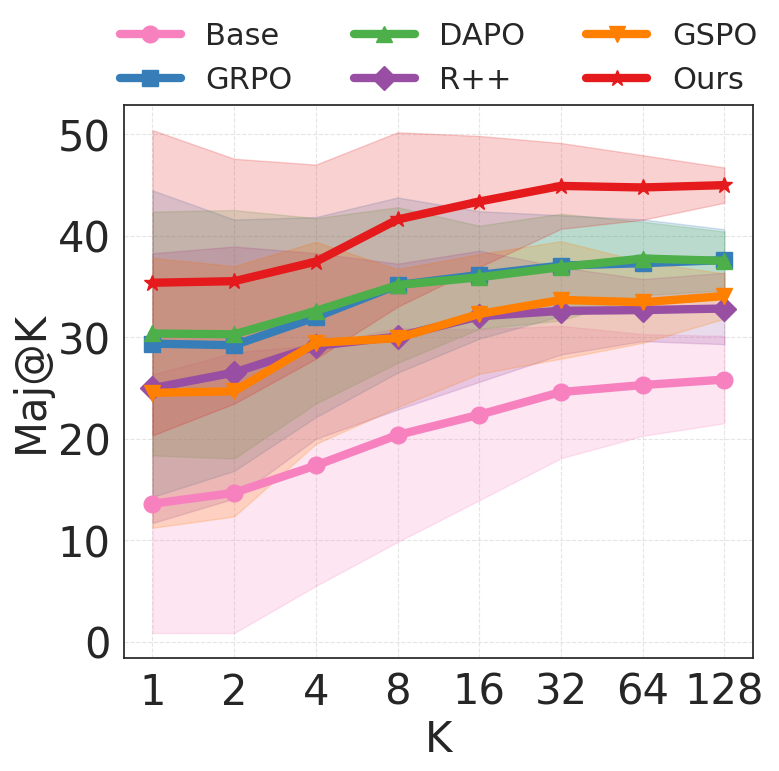

In [122]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_figure_with_k_std(df, labels=['Base', 'GRPO', 'DAPO', 'R++', 'GSPO', 'Ours'], col_name='Maj@K', save_name=None):
    # 确保模型名称列存在
    df['model'] = labels

    # 创建数据框用于绘图，包括均值和标准差
    plot_data = []
    for model in labels:
        model_row = df[df['model'] == model].iloc[0]
        for k in df.columns.drop(['model'] + [col for col in df.columns if '_std' in col]):
            if k == 'model':
                continue
            try:
                k_val = int(k)
                mean_val = model_row[k]
                std_col = f"{k}_std"
                std_val = model_row[std_col] if std_col in df.columns else None
                plot_data.append({
                    'model': model,
                    'K': k_val,
                    'performance': mean_val,
                    'std': std_val
                })
            except:
                continue

    plot_df = pd.DataFrame(plot_data)

    # 设置样式
    sns.set(style="white", font_scale=1.0)

    # 创建图形
    plt.figure(figsize=(8, 8))
    models = labels
    marker_list = ['o', 's', '^', 'D', 'v', '*']
    min_length = min(len(models), len(marker_list))
    model_markers = dict(zip(models[:min_length], marker_list[:min_length]))

    # 绘制带误差线的折线图
    ax = plt.gca()
    set1_colors = [

        "#F781BF",  # Pink
        "#377EB8",  # Blue
        "#4DAF4A",  # Green
        "#984EA3",  # Purple
        "#FF7F00",  # Orange
        "#E41A1C",  # Red
        # "#FFFF33",  # Yellow
        # "#A65628",  # Brown
        
        # "#999999"   # Gray
    ]
    colors = set1_colors
    # colors = sns.color_palette('Set1', n_colors=len(models))
    # colors[0], colors[-1] = colors[-1], colors[0]

    for i, model in enumerate(models):
        model_data = plot_df[plot_df['model'] == model].sort_values('K')
        k_values = model_data['K'].values
        mean_values = model_data['performance'].values
        std_values = model_data['std'].values if model_data['std'].notna().all() else None

        # 绘制主线条
        ax.plot(k_values, mean_values,
                marker=model_markers[model],
                linewidth=6,
                markersize=12,
                color=colors[i],
                # alpha=0.8,
                label=model)

        # 添加标准差作为置信区间（误差带）
        if std_values is not None:
            ax.fill_between(k_values,
                           np.clip(mean_values - std_values, 0, 100),
                           mean_values + std_values,
                           alpha=0.2,
                           color=colors[i])

    # 设置横轴为以 2 为底的对数坐标
    ax.set_xscale('log', base=2)
    ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)

    # 自定义 x 轴刻度和标签
    Ks = sorted([k for k in plot_df['K'].unique() if k in [1, 2, 4, 8, 16, 32, 64, 128]])
    ax.set_xticks(Ks)
    ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))

    # 标签与标题
    plt.xlabel('K', fontsize=30)
    plt.ylabel(col_name, fontsize=30)
    plt.xticks(fontsize=30)
    plt.yticks(fontsize=30)

    # 图例位置
    plt.legend(ncol=3, fontsize='22', frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.2))

    # 紧凑布局
    plt.tight_layout()

    if save_name is not None:
        plt.savefig(f"figures/{save_name}.pdf", dpi=600, bbox_inches='tight')

    plt.show()
    return


plot_figure_with_k_std(avg_4_dataset_majk_std, save_name="Maj_at_k_qwen34b")
# plot_figure_with_k_std(avg_4_dataset_majk_std, )

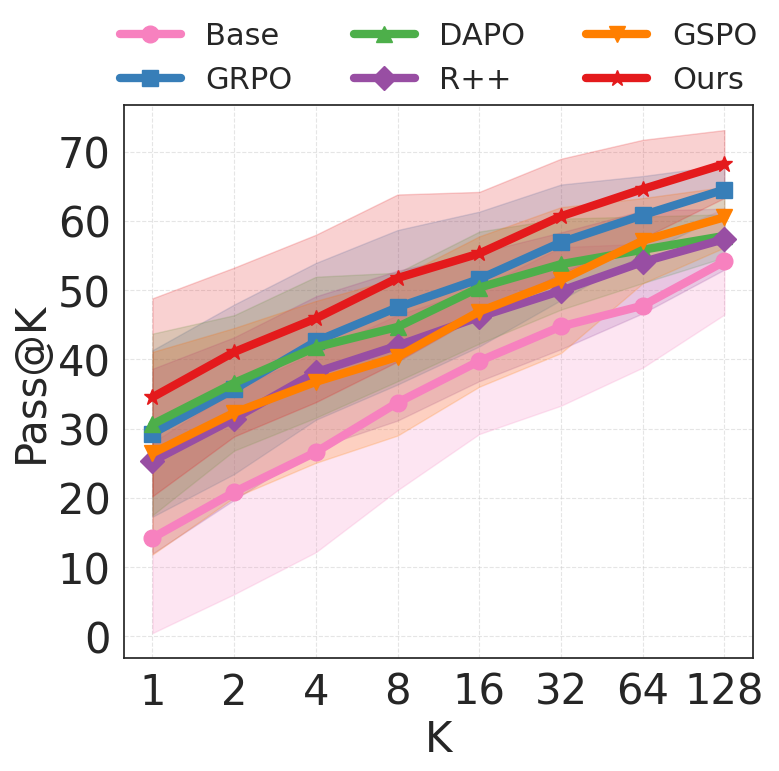

In [124]:
plot_figure_with_k_std(avg_4_dataset_passk_std, col_name='Pass@K', save_name="pass_at_k_qwen34b")

In [98]:
# # todo 

# # ===== 使用 SciencePlots 样式 =====
# # plt.style.use(['science', 'no-latex'])  # 'science' 提供出版级样式；'no-latex' 避免依赖 LaTeX
# # 使用 melt 将宽表转为长表，便于 seaborn 绘图
# def plot_figure_with_k(df, labels= ['Base', 'GRPO', 'DAPO', 'R++', 'Ours'], col_name='Maj@K', save_name=None):
# # labels = ['Base', 'GRPO', 'DAPO', 'R++', 'Ours']
#     df['model'] = labels
#     df_melted = df.melt(id_vars='model', var_name='K', value_name='performance')

#     # 转换 batch_size 为数值类型（以便正确排序）
#     df_melted['K'] = pd.to_numeric(df_melted['K'])
#     # sns.set_palette("colorblind")
#     # 设置样式
#     sns.set(style="white", font_scale=1.0)

#     # palette = ["#062456","#1d3867","#334d77","#4a6188","#627799","#7a8ca9","#93a2ba","#adb9cb","#c8d0dc","#e3e7ee"][::-1]
#     # 创建图形
#     plt.figure(figsize=(8, 8))
#     models = labels
#     marker_list = ['o', 's', '^', 'D', 'v', '*']  # 圆、方、上三角、菱形、星形
#     min_length = min(len(models), len(marker_list))
#     # 构建 marker 字典
#     model_markers = dict(zip(models[:min_length], marker_list[:min_length]))

#     ax = sns.lineplot(
#         data=df_melted,
#         x='K',
#         y='performance',
#         hue='model',
#         style='model',          # 启用按 model 分配样式
#         markers=model_markers,  # 指定 marker
#         linewidth=6,
#         markersize=12,
#         dashes=False,            # 保持所有线条为实线
#         palette='Set1',
#         alpha=0.8
#     )


#     # 设置横轴为以 2 为底的对数坐标
#     ax.set_xscale('log', base=2)
#     ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)

#     # 自定义 x 轴刻度和标签
#     Ks = [1, 2, 4, 8, 16, 32, 64, 128]
#     ax.set_xticks(Ks)
#     ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))

#     # 标签与标题
#     plt.xlabel('K', fontsize=30)
#     plt.ylabel(col_name, fontsize=30)
#     plt.xticks(fontsize=30)
#     plt.yticks(fontsize=30)
#     # plt.title('Performance vs Batch Size (Log Scale)', fontsize=14, fontweight='bold')

#     # 图例位置（右侧不遮挡）
#     plt.legend(ncol=3, fontsize='22', frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.2))

#     # 紧凑布局
#     plt.tight_layout()

#     if save_name is not None:
#         plt.savefig(f"figures/{save_name}.pdf", dpi=600, bbox_inches='tight')
#     # 显示
#     plt.show()
#     return 

# plot_figure_with_k(avg_4_dataset_majk, save_name='Maj_at_k_qwen34b')

In [51]:
df_pass_at_k_aime2024 = show_pass_at_k_results(model_list, 'aime2024')
df_pass_at_k_aime2025 = show_pass_at_k_results(model_list, 'aime2025')
df_pass_at_k_amc23 = show_pass_at_k_results(model_list, 'amc23')
df_pass_at_k_hmmt25 = show_pass_at_k_results(model_list, 'hmmt25')

In [62]:
df_pass_at_k_hmmt25

,model,1,2,4,8,16,32,64,128
0,Qwen3-4B-Base_sc128,0.989583,1.843012,3.238361,5.242763,7.932048,12.005624,18.359580,26.666667
1,deepscaler_qwen34b_grpo_bsz128_global_step_314...,7.864583,11.343914,15.359061,19.500968,23.487037,27.401021,30.725831,33.333333
2,deepscaler_qwen34b_grpo_dapo_global_step_179_s...,6.718750,10.126722,13.737570,17.496411,20.995443,23.907162,26.560281,30.000000
3,deepscaler_qwen34b_reinforce_plus_plus_baselin...,4.192708,6.784777,10.232434,14.895278,20.861881,27.294025,32.570495,36.666667
4,deepscaler_qwen34b_ent_inc_pos_clip02_focalcre...,10.703125,14.345062,19.013490,24.381710,29.688247,34.639190,39.965564,46.666667


In [52]:
pass_at_k_avg4_df = weighted_average_dataframes([df_pass_at_k_aime2024, df_pass_at_k_aime2025, df_pass_at_k_amc23, df_pass_at_k_hmmt25], [30, 30, 40, 30])
pass_at_k_avg4_df

,model,1,2,4,8,16,32,64,128
0,Qwen3-4B-Base_sc128,14.083534,20.206709,26.745744,33.278259,39.283100,44.954161,51.040315,57.779058
1,deepscaler_qwen34b_grpo_bsz128_global_step_314...,30.120192,35.947910,41.855194,47.681394,53.047254,57.988251,62.559004,66.923077
2,deepscaler_qwen34b_grpo_dapo_global_step_179_s...,30.612981,36.152710,41.120996,45.603286,49.867935,53.942109,57.426709,60.000000
3,deepscaler_qwen34b_reinforce_plus_plus_baselin...,25.546875,31.424232,36.574991,41.480276,46.342568,51.251623,56.055156,60.769231
4,deepscaler_qwen34b_ent_inc_pos_clip02_focalcre...,34.248798,41.094886,47.527937,53.431763,58.286710,62.340755,66.707566,72.307692


In [99]:
# plot_figure_with_k(pass_at_k_avg4_df, col_name='Pass@K', save_name="pass_at_k_qwen34b")

In [147]:
def show_budget(ckpts, datasets, metric='avg_acc'):
    results = {}
    results['model'] = ckpts
    for dataset_name in datasets:
        results[dataset_name] = []
        results[dataset_name + "_32K"] = []
        num_rows = get_dataset_num(dataset_name)
        for ckpt in ckpts:
            result_path = os.path.join(f"results/{dataset_name}/{ckpt}/result.json")
            if not os.path.exists(result_path):
                result_path = result_path.replace("sc128", "sc16")
                result_path = result_path.replace("sc32", "sc16")
                if not os.path.exists(result_path):
                    # print(f"Warning: Result file for {dataset_name} at checkpoint {ckpt} not found.")
                    results[dataset_name].append(np.nan)
                    results[dataset_name + "_len"].append(np.nan)
                    continue
            with open(result_path, 'r') as f:
                data = json.load(f)
            if data['count'] != num_rows:
                print(f"Warning: The number of rows in {dataset_name} for checkpoint {ckpt} does not match the expected count.")
            results[dataset_name].append(data['score'][metric] * 100)
            
            # 32K path 
            if "_8192" in result_path:
                result_path = result_path.replace("_8192", "")
            result_32K_path = result_path.replace("sc128", "sc128_31000")
            if not os.path.exists(result_32K_path):
                result_32K_path = result_32K_path.replace("sc128_31000", "sc16_31000")
                if not os.path.exists(result_32K_path):
                    results[dataset_name + "_32K"].append(np.nan)
                    continue
            with open(result_32K_path, 'r') as f:
                data_32K = json.load(f)
            if data_32K['count'] != num_rows:
                print(f"Warning: The number of rows in {dataset_name} for checkpoint {ckpt} does not match the expected count.")
            
            results[dataset_name + "_32K"].append(data_32K['score'][metric] * 100)
            
    df = pd.DataFrame(results)
    
    return df

In [163]:

def show_budget_std_results(ckpts, datasets):
    results = {}
    results['model'] = ckpts
    
    for dataset_name in datasets:
        results[dataset_name] = []
        results[dataset_name + "_std"] = []
        # cur_run = max(runs, 10)

        for ckpt in ckpts:
            cache_path = os.path.join(f"results/{dataset_name}/{ckpt}/cache.jsonl")
            # result_path = os.path.join(f"results/{dataset}/{ckpt}/result.json")
            if not os.path.exists(cache_path):
                
                cache_path = cache_path.replace("sc128", "sc16")
                cache_path = cache_path.replace("sc32", "sc16")
                if not os.path.exists(cache_path):
                    results[dataset_name].append(np.nan)
                    results[dataset_name + "_std"].append(np.nan)
                    continue

            data = [json.loads(line) for line in open(cache_path)]
            all_pass1_acc = []
            all_pass1_std = []
            for task_log in data:
                all_run_acc = []
                # std_acc = []
                for i in range(10):
                    sample_idx = np.random.choice(len(task_log['predictions']), size=128, replace=True)
                    accuracy = [int(task_log['all_acc'][idx]) for idx in sample_idx]
                
                    acc = np.mean(accuracy)
                    all_run_acc.append(acc)
                    # acc_std = np.std(accuracy)
                acc = np.mean(all_run_acc)
                acc_std = np.std(all_run_acc)
                
                all_pass1_acc.append(acc)
                all_pass1_std.append(acc_std)
            
            results[dataset_name + "_std"].append(np.mean(all_pass1_std) * 100)
            results[dataset_name].append(np.mean(all_pass1_acc) * 100)
            
        

    df = pd.DataFrame(results)

    return df

In [164]:
# budget_df = show_budget(model_list[1:], datasets[:4])
# budget_df
budget_8k = show_budget_std_results(model_list[1:], datasets[:4])
def transform_8k_32k(model):
    if "_8192" in model:
        model = model.replace("_8192", "")
    model_32K_path = model.replace("sc128", "sc128_31000")
    # if not os.path.exists(model_32K_path):
    #     model_32K_path = model_32K_path.replace("sc128_31000", "sc16_31000")
    return model_32K_path

model_list_32k = [transform_8k_32k(x) for x in model_list[1:]]
# print(model_list_32k)
budget_32k = show_budget_std_results(model_list_32k, datasets[:4])

In [167]:
budget_8k
budget_32k
budget_32k.loc[4, 'aime2025'] = 24.0625
budget_32k.loc[4, 'hmmt25'] = 13.125
# print(model_list_32k)

In [162]:
# budget_32k = budget_32k[:-1]
budget_32k

,model,aime2024,aime2024_std,aime2025,aime2025_std,amc23,amc23_std,hmmt25,hmmt25_std
0,deepscaler_qwen34b_grpo_bsz128_global_step_314...,22.270833,1.960608,18.583333,2.602818,60.671875,4.909178,7.604167,1.538839
1,deepscaler_qwen34b_grpo_dapo_global_step_179_s...,21.604167,4.731389,18.854167,2.491187,63.718750,4.552305,5.875000,1.594795
2,deepscaler_qwen34b_reinforce_plus_plus_baselin...,14.979167,2.705620,12.708333,2.351617,58.890625,5.639559,5.041667,1.564067
3,deepscaler_qwen34b_grpo_gspo_global_step_314_s...,15.687500,2.927542,13.375000,2.721036,58.953125,5.134600,3.812500,1.449212
4,deepscaler_qwen34b_ent_inc_pos_scale00015_foca...,26.833333,3.967366,24.062500,3.129099,71.921875,5.817153,13.125000,2.617909


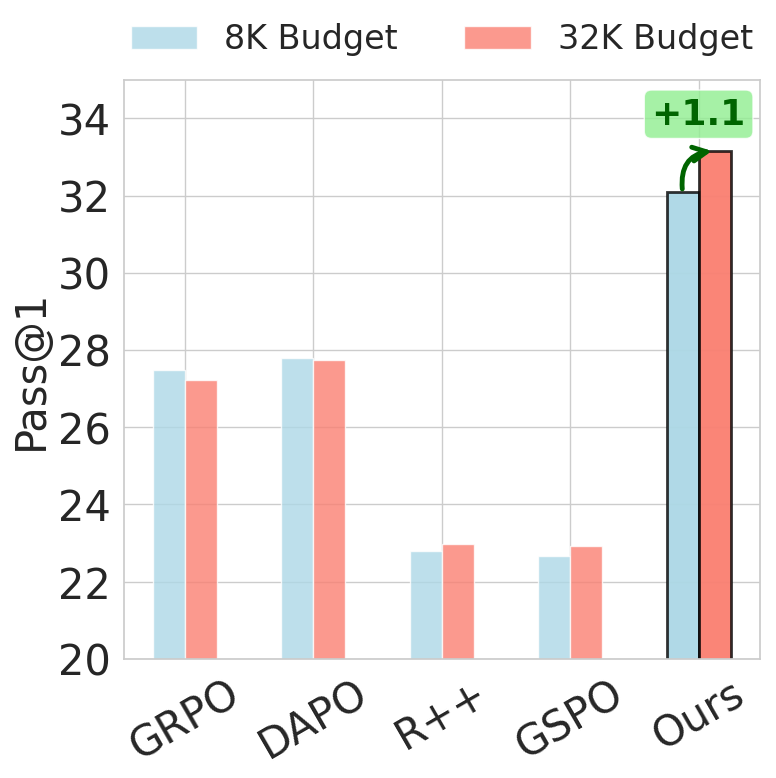

Detailed Performance Data:
  method  avg_8k  avg_32k  improvement
0   GRPO   27.47    27.23        -0.25
1   DAPO   27.79    27.73        -0.05
2    R++   22.78    22.98         0.20
3   GSPO   22.66    22.93         0.27
4   Ours   32.10    33.17         1.07


In [159]:


df = budget_df

# 计算每个模型在8K和32K下的平均性能
df['avg_8k'] = (df['aime2024'] + df['aime2025'] + df['amc23'] + df['hmmt25']) / 4
df['avg_32k'] = (df['aime2024_32K'] + df['aime2025_32K'] + df['amc23_32K'] + df['hmmt25_32K']) / 4

# 计算性能提升
df['improvement'] = df['avg_32k'] - df['avg_8k']

# 创建模型标签（用简单的代号）
model_labels = ['GRPO', 'DAPO', 'R++', "GSPO", 'Ours']
df['method'] = model_labels

# 设置绘图风格
plt.figure(figsize=(8, 8))
sns.set_style("whitegrid")
# plt.rcParams['font.size'] = 30

# 创建子图1：平均性能对比
# plt.subplot(2, 1, 1)
x = np.arange(len(df))
width = 0.25

bars1 = plt.bar(x - width/2, df['avg_8k'], width, label='8K Budget', alpha=0.8, color='lightblue')
bars2 = plt.bar(x + width/2, df['avg_32k'], width, label='32K Budget', alpha=0.8, color='salmon')

# 特别突出我们的方法（最后一行）
plt.bar(x[-1] - width/2, df['avg_8k'].iloc[-1], width, alpha=0.8, color='lightblue', edgecolor='black', linewidth=2)
plt.bar(x[-1] + width/2, df['avg_32k'].iloc[-1], width, alpha=0.8, color='salmon', edgecolor='black', linewidth=2)


# Add arc arrow for our method
our_idx = -1
x_8k = x[our_idx] - width/2
x_32k = x[our_idx] + width/2
y_8k = df['avg_8k'].iloc[our_idx]
y_32k = df['avg_32k'].iloc[our_idx]

# Calculate middle point for arc (position above the bars)
mid_x = (x_8k + x_32k) / 2
mid_y = max(y_8k, y_32k) + 0.5

# Create curved arrow using annotation
plt.annotate('',
             xy=(x_32k, y_32k),
             xytext=(x_8k, y_8k),
             arrowprops=dict(arrowstyle='->',
                           color='darkgreen',
                           lw=3.5,
                           mutation_scale=25,
                           connectionstyle=f'arc3,rad=-0.5'),
             zorder=10)

# Add improvement value text above the arc
improvement = df['improvement'].iloc[our_idx]
plt.text(mid_x, mid_y,
         f'+{improvement:.1f}',
         ha='center', va='bottom',
         fontsize=26, fontweight='bold', color='darkgreen',
         bbox=dict(boxstyle="round,pad=0.2", facecolor='lightgreen', alpha=0.8))


plt.ylabel('Pass@1', fontsize=30)
# plt.title('Performance Comparison: 8K vs 32K Budget', fontsize=14, fontweight='bold')
plt.xticks(x, df['method'], fontsize=30, rotation=30)
plt.yticks(fontsize=30)
plt.legend(fontsize=24, bbox_to_anchor=(0.5, 1.15), loc='upper center', ncol=2, frameon=False)


# add_labels(bars1)
# add_labels(bars2)
plt.ylim(20, 35)

plt.tight_layout()
# plt.subplots_adjust(top=0.92, bottom=0.12)
plt.savefig("figures/qwen34b_scale32k.pdf", dpi=600, bbox_inches='tight')
# 显示图表
plt.show()

# 打印详细数据
print("Detailed Performance Data:")
print("="*80)
print(df[['method', 'avg_8k', 'avg_32k', 'improvement']].round(2))


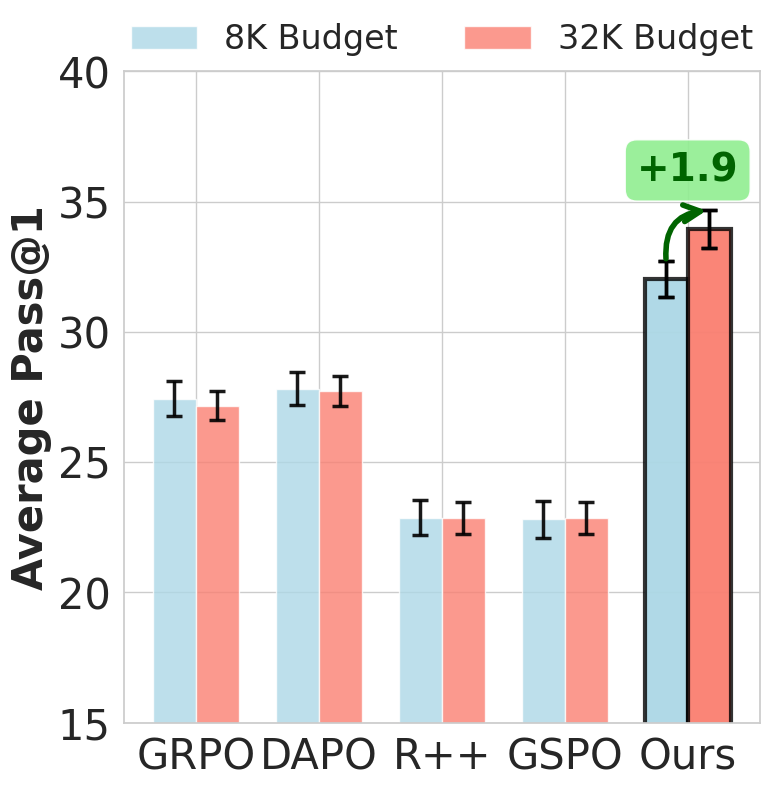

In [169]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 假设你有两个DataFrame: df_8k 和 df_32k
# df_8k 包含8K预算下的数据，df_32k 包含32K预算下的数据
# 两个DataFrame的结构与你提供的示例一致

# 计算每个模型在8K和32K下的平均性能和标准差
def calculate_avg_with_std(df):
    """计算平均性能和合并标准差"""
    # 计算平均性能
    avg_performance = (df['aime2024'] + df['aime2025'] + df['amc23'] + df['hmmt25']) / 4

    # 计算合并标准差（假设各基准测试独立，使用平方和开方）
    std_combined = np.sqrt(
        df['aime2024_std']**2 +
        df['aime2025_std']**2 +
        df['amc23_std']**2 +
        df['hmmt25_std']**2
    ) / 4

    return avg_performance, std_combined

# 计算8K和32K的平均性能和标准差
avg_8k, std_8k = calculate_avg_with_std(budget_8k)
avg_32k, std_32k = calculate_avg_with_std(budget_32k)

# 创建结果DataFrame
df_results = pd.DataFrame({
    'model': budget_8k['model'],
    'avg_8k': avg_8k,
    'std_8k': std_8k,
    'avg_32k': avg_32k,
    'std_32k': std_32k,
    'improvement': avg_32k - avg_8k
})

# 创建模型标签（用简单的代号）
model_labels = ['GRPO', 'DAPO', 'R++', "GSPO", 'Ours']
df_results['method'] = model_labels

# 设置绘图风格
plt.figure(figsize=(8, 8))
sns.set_style("whitegrid")
# plt.rcParams['font.size'] = 12

# 绘制柱状图和误差条
x = np.arange(len(df_results))
width = 0.35
error_params = {
    'ecolor': 'black',      # 误差线颜色
    'capsize': 6,           # 误差线帽的大小
    'capthick': 2.5,        # 误差线帽的粗细
    'elinewidth': 2.5,      # 误差线本身的粗细
    'alpha': 0.9            # 透明度
}

# 绘制8K的柱状图和误差条
bars1 = plt.bar(
    x - width/2,
    df_results['avg_8k'],
    width,
    label='8K Budget',
    alpha=0.8,
    color='lightblue',
    yerr=df_results['std_8k'],
    capsize=5,
    error_kw=error_params
    # edgecolor='black',
    # linewidth=1
)

# 绘制32K的柱状图和误差条
bars2 = plt.bar(
    x + width/2,
    df_results['avg_32k'],
    width,
    label='32K Budget',
    alpha=0.8,
    color='salmon',
    yerr=df_results['std_32k'],
    capsize=5,
    error_kw=error_params
    # edgecolor='black',
    # linewidth=1
)

# 特别突出我们的方法（最后一行）
our_idx = -1
plt.bar(
    x[our_idx] - width/2,
    df_results['avg_8k'].iloc[our_idx],
    width,
    alpha=0.8,
    color='lightblue',
    edgecolor='black',
    linewidth=3,
    yerr=df_results['std_8k'].iloc[our_idx],
    capsize=6,
    error_kw=error_params
)
plt.bar(
    x[our_idx] + width/2,
    df_results['avg_32k'].iloc[our_idx],
    width,
    alpha=0.8,
    color='salmon',
    edgecolor='black',
    linewidth=3,
    yerr=df_results['std_32k'].iloc[our_idx],
    capsize=6,
    error_kw=error_params
)

# 添加弯曲箭头显示提升
x_8k = x[our_idx] - width/2
x_32k = x[our_idx] + width/2
y_8k = df_results['avg_8k'].iloc[our_idx]
y_32k = df_results['avg_32k'].iloc[our_idx]

# 计算箭头位置（考虑误差条）
y_8k_with_err = y_8k + df_results['std_8k'].iloc[our_idx]
y_32k_with_err = y_32k + df_results['std_32k'].iloc[our_idx]

# 计算中间点
mid_x = (x_8k + x_32k) / 2
mid_y = max(y_8k_with_err, y_32k_with_err) + 0.8

# 创建弯曲箭头
plt.annotate('',
             xy=(x_32k, y_32k_with_err),
             xytext=(x_8k, y_8k_with_err),
             arrowprops=dict(arrowstyle='->',
                           color='darkgreen',
                           lw=4,
                           mutation_scale=30,
                           connectionstyle=f'arc3,rad=-0.5'),
             zorder=10)

# 添加提升值文本
improvement = df_results['improvement'].iloc[our_idx]
plt.text(mid_x, mid_y,
         f'+{improvement:.1f}',
         ha='center', va='bottom',
         fontsize=28, fontweight='bold', color='darkgreen',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen', alpha=0.9))

# 添加数值标签（可选）
def add_labels(bars, stds):
    for bar, std in zip(bars, stds):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + std + 0.3,
                 f'{height:.1f}±{std:.1f}',
                 ha='center', va='bottom', fontsize=10, rotation=0)

# add_labels(bars1, df_results['std_8k'])
# add_labels(bars2, df_results['std_32k'])

plt.ylabel('Average Pass@1', fontsize=30, fontweight='bold')
plt.xticks(x, df_results['method'], fontsize=30, rotation=0)
plt.yticks(fontsize=30)
plt.legend(fontsize=24, bbox_to_anchor=(0.5, 1.12), loc='upper center', ncol=2, frameon=False)

# 调整y轴范围以适应误差条和标签
# y_min = min((df_results['avg_8k'] - df_results['std_8k']).max(),
#             (df_results['avg_32k'] - df_results['std_32k']).max()) - 2
# y_max = max((df_results['avg_8k'] + df_results['std_8k']).max(),
#             (df_results['avg_32k'] + df_results['std_32k']).max()) + 4
plt.ylim(15, 40)

plt.tight_layout()
plt.savefig("figures/qwen34b_scale32k_with_std.pdf", dpi=600, bbox_inches='tight')
plt.show()

# 打印统计信息
# print("\n统计摘要:")
# print(df_results[['method', 'avg_8k', 'std_8k', 'avg_32k', 'std_32k', 'improvement']].to_string(index=False))


In [346]:
med_datasets = ['medqa', 'medmcqa', 'pubmedqa', 'medxpert', 'mmlu_pro_med']
# model_list = ['Qwen3-4B-Base_sc16', 'Qwen3-4B-Base_sc128', 'deepscaler_qwen34b_grpo_bsz128_global_step_314_sc128', 'deepscaler_qwen34b_grpo_new_global_step_629_sc16', 'deepscaler_qwen34b_grpo_neg_new_reward_last_global_step_629_sc16', 'deepscaler_qwen34b_grpo_neg_new_reward_global_step_629_sc16', 'deepscaler_qwen34b_ent_inc_bsz128_global_step_314_sc128', 'deepscaler_qwen34b_grpo_dynamicrollout_max_bsz128_global_step_314_sc128']
med_model_list = ['Qwen3-4B-Base_sc4', 'medqa_medmcqa_qwen34b_grpo_wkl_global_step_671_sc4', 'Llama-3.1-8B-Instruct_sc4', 'medqa_medmcqa_llama3.1_8b_grpo_global_step_671_sc4', 'medqa_medmcqa_llama3.1_8b_ent_inc_pos_scale00015_focalcredit_global_step_335_sc4']


In [348]:
med_df = show_results(med_model_list, med_datasets, metric='pass@1')
# med_df.loc[:, ~med_df.columns.str.contains('_len')]
med_df


,model,medqa,medqa_pass@K,medmcqa,medmcqa_pass@K,pubmedqa,pubmedqa_pass@K,medxpert,medxpert_pass@K,mmlu_pro_med,mmlu_pro_med_pass@K
0,Qwen3-4B-Base_sc4,49.783975,75.412412,46.402104,76.332776,70.65,87.4,3.959184,12.816327,46.693811,76.026059
1,medqa_medmcqa_qwen34b_grpo_wkl_global_step_671...,65.553810,80.047133,60.172125,71.838393,74.10,80.0,12.408163,23.265306,66.270358,77.785016
2,Llama-3.1-8B-Instruct_sc4,60.958366,81.853888,55.414774,77.073870,75.55,81.2,11.459184,25.918367,54.951140,76.091205
3,medqa_medmcqa_llama3.1_8b_grpo_global_step_671...,70.149254,84.446190,63.638537,76.117619,79.05,82.0,16.285714,29.346939,65.570033,77.394137
4,medqa_medmcqa_llama3.1_8b_ent_inc_pos_scale000...,72.034564,86.174391,64.588812,78.293091,78.95,81.6,17.530612,32.693878,66.693811,78.957655


In [9]:
qwen38b_model_list = ['Qwen3-8B-Base_sc128']
show_results(qwen38b_model_list, datasets, metric='pass@1')

,model,aime2024,aime2024_pass@K,aime2025,aime2025_pass@K,amc23,amc23_pass@K,hmmt25,hmmt25_pass@K,math,math_pass@K,olympiad_bench,olympiad_bench_pass@K
0,Qwen3-8B-Base_sc128,9.166667,53.333333,5.911458,40.0,39.140625,95.0,1.510417,23.333333,56.3125,91.4,34.509466,66.092943


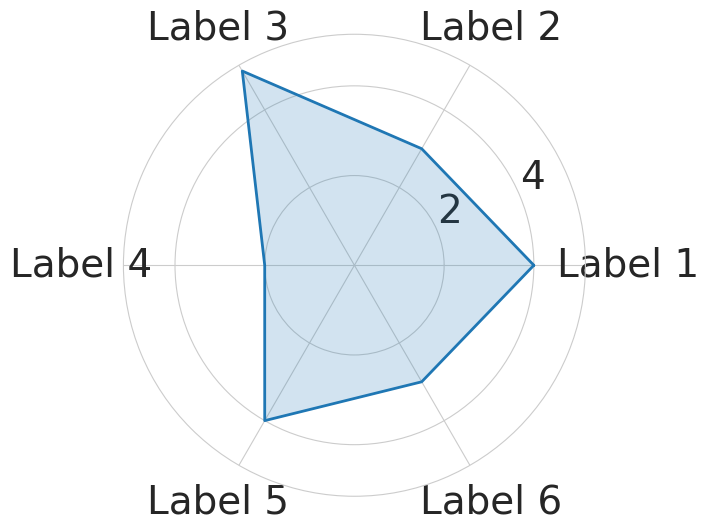

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
labels = ['Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label 6']
values = [4, 3, 5, 2, 4, 3]
rotations = [90, 30, -30, -90, 30, -30]

num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
values += values[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, values, color='#1f77b4', linewidth=2)
ax.fill(angles, values, color='#1f77b4', alpha=0.2)

# 设置初始标签
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

# 关键：调整坐标轴标签的外间距，避免中心点就在圆周上
ax.tick_params(axis='x', pad=20) 

plt.draw()

# 核心：修改每一个 label 的旋转行为
for label, angle in zip(ax.get_xticklabels(), rotations):
    label.set_rotation(120)
    # 强制以标签内容的中心作为旋转中心
    label.set_rotation_mode('anchor') 
    label.set_horizontalalignment('center')
    label.set_verticalalignment('center')
    
    # 如果你想让标签离圆心更远，可以动态微调其位置
    # x, y = label.get_position()
    # label.set_position((x, y + 0.2))

# plt.title("Center-Rotated Axis Labels", pad=40)
plt.show()